# 04 — LightGBM Baseline

Full primary model training run on **synthetic** BTCUSDT data.
1. Synthetic 1-min OHLCV + feature pipeline
2. Triple-barrier labels (pt_sl=(10,10)) and sample weights
3. Optuna hyperparameter search with PurgedKFold
4. Feature importance (gain, split) and permutation importance
5. CPCV C(6,2)=15 path Sharpe distribution
6. Phase 6 Report
7. Save model to registry

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tessera.config import TesseraSettings, seed_everything

# Ensure project root is CWD so registry paths (./models/) resolve correctly
if not Path("pyproject.toml").exists():
    os.chdir("..")

settings = TesseraSettings()
seed_everything(settings.random_seed)
print(f"Working directory: {Path.cwd()}")
print(f"Models root:       {settings.models_root.resolve()}")

Working directory: /Users/yashlunawat/code/tools/Tessera
Models root:       /Users/yashlunawat/code/tools/Tessera/models


## 1. Synthetic Data & Feature Pipeline

In [2]:
from tessera.features import (
    FeaturePipeline,
    GarmanKlass,
    LogReturn,
    MicroPrice,
    OrderFlowImbalance,
    Parkinson,
    RealizedVol,
    SpreadBps,
    VolOfVol,
)

feature_list = [
    LogReturn(horizon=1),
    LogReturn(horizon=5),
    LogReturn(horizon=60),
    RealizedVol(window=60),
    Parkinson(window=60),
    GarmanKlass(window=60),
    VolOfVol(window=60),
    OrderFlowImbalance(depth=1),
    MicroPrice(),
    SpreadBps(),
]
pipeline = FeaturePipeline(feature_list)

rng = np.random.default_rng(42)
n = 90 * 24 * 60
idx = pd.date_range("2024-01-01", periods=n, freq="1min")

log_ret = rng.normal(0, 0.0003, n)
log_ret[0] = 0
close_arr = 42000.0 * np.exp(np.cumsum(log_ret))
high_arr = close_arr * (1 + rng.uniform(0.0001, 0.002, n))
low_arr = close_arr * (1 - rng.uniform(0.0001, 0.002, n))
open_arr = close_arr * np.exp(rng.normal(0, 0.0002, n))
volume = rng.uniform(0.5, 100, n)
spread = rng.uniform(0.5, 8, n)

symbol = "SYNTHETIC_BTCUSDT"
df = pd.DataFrame(
    {
        "event_time": idx,
        "open": open_arr,
        "high": high_arr,
        "low": low_arr,
        "close": close_arr,
        "volume": volume,
        "bid_price": close_arr - spread / 2,
        "ask_price": close_arr + spread / 2,
        "bid_size": rng.uniform(0.1, 10, n),
        "ask_size": rng.uniform(0.1, 10, n),
        "funding_rate": np.where(rng.random(n) > 0.875, rng.normal(0.0001, 0.0003, n), np.nan),
        "spot_price": close_arr * (1 + rng.normal(0, 0.0002, n)),
    },
    index=idx,
)

print(f"Synthetic data: {len(df):,} rows  |  ${df['close'].min():.0f} – ${df['close'].max():.0f}")

Synthetic data: 129,600 rows  |  $35814 – $46232


## 2. Triple-Barrier Labels & Sample Weights

In [3]:
from tessera.labels.sample_weights import get_sample_weights_by_return
from tessera.labels.triple_barrier import (
    apply_triple_barrier,
    compute_volatility,
    get_bins,
    make_events,
)

feat_df = pipeline.compute(df, symbol=symbol)
close = feat_df["close"]
vol = compute_volatility(close, span=1440, min_periods=60)
timestamps = pd.DatetimeIndex(close.dropna().index)[60:]
valid = timestamps[vol.reindex(timestamps).notna()][::60]
print(f"Sampled events: {len(valid)}")

events = make_events(close, valid, vol, vertical_bars=240)
# pt_sl=(10,10): barriers at ±10σ produce ~9% label=0 on 1-min GBM
barriers = apply_triple_barrier(events, close, pt_sl=(10.0, 10.0))
labels = get_bins(barriers, close)
print(f"Label distribution:\n{labels['bin'].value_counts().sort_index()}")

feature_cols = [f.name for f in feature_list]
X = feat_df.loc[labels.index, feature_cols].dropna()  # noqa: N806
common = X.index.intersection(labels.index)
X = X.loc[common]  # noqa: N806
y = labels.loc[common, "bin"]
t1 = events.loc[common, "t1"]
sw = get_sample_weights_by_return(t1, close)
fwd_ret = close.pct_change().shift(-1).reindex(common).fillna(0)
print(f"Training set: {len(X):,} samples, {X.shape[1]} features")

2026-05-17 21:07:10 [debug    ] computing_feature              feature=log_return_1 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:10 [debug    ] computing_feature              feature=log_return_5 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:10 [debug    ] computing_feature              feature=log_return_60 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:11 [debug    ] computing_feature              feature=realized_vol_60 symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:11 [debug    ] computing_feature              feature=parkinson_vol_60 symbol=SYNTHETIC_BTCUSDT


...

2026-05-17 21:07:11 [debug    ] computing_feature              feature=spread_bps symbol=SYNTHETIC_BTCUSDT


2026-05-17 21:07:11 [debug    ] computing_feature              feature=vol_of_vol_60 symbol=SYNTHETIC_BTCUSDT


Sampled events: 2159


Label distribution:
bin
-1    1043
 0     196
 1     920
Name: count, dtype: int64


Training set: 2,158 samples, 10 features


## 3. Optuna Hyperparameter Search

In [4]:
from tessera.models.lightgbm_model import PrimaryLightGBMModel

model = PrimaryLightGBMModel(seed=settings.random_seed)
study = model.tune(
    X,
    y,
    t1,
    sample_weight=sw.values,
    forward_returns=fwd_ret,
    n_trials=20,  # 100 in production
    n_splits=3,
)

card = model.get_model_card()
print(f"Best trial accuracy: {study.best_value:.4f}")
if card.cv_scores:
    cv = card.cv_scores
    print(f"CV Sharpe:       {cv.mean_sharpe:.4f} ± {cv.std_sharpe:.4f}")
    print(f"Deflated Sharpe: {cv.deflated_sharpe:.4f}  (n_trials={cv.n_trials})")

2026-05-17 21:07:20 [info     ] optuna_complete                best_params={'num_leaves': 241, 'max_depth': 5, 'min_data_in_leaf': 120, 'learning_rate': 0.01720467529929385, 'feature_fraction': 0.6279993375278882, 'bagging_fraction': 0.5975252767975879, 'reg_alpha': 0.620396104701887, 'reg_lambda': 0.027603248905793416, 'bagging_freq': 1} best_value=0.4837744037500644


Best trial accuracy: 0.4838
CV Sharpe:       0.0004 ± 0.0328
Deflated Sharpe: 0.0000  (n_trials=20)


## 4. Optuna Study Plots

/var/folders/vj/t55q5xc95319bhqdn3v2s0zr0000gn/T/ipykernel_15686/2944421180.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


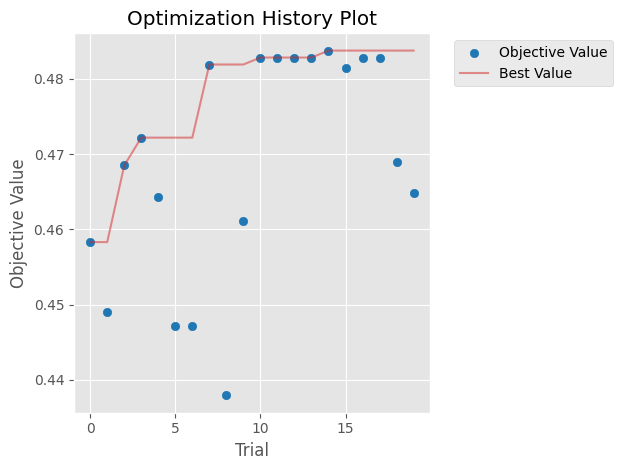

/var/folders/vj/t55q5xc95319bhqdn3v2s0zr0000gn/T/ipykernel_15686/2944421180.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


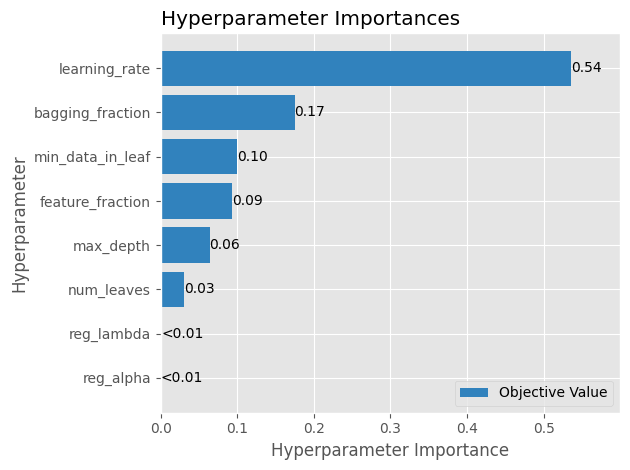

In [5]:
import optuna

fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig("docs/figures/04_optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.savefig("docs/figures/04_optuna_param_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Importance (Gain, Split, Permutation)

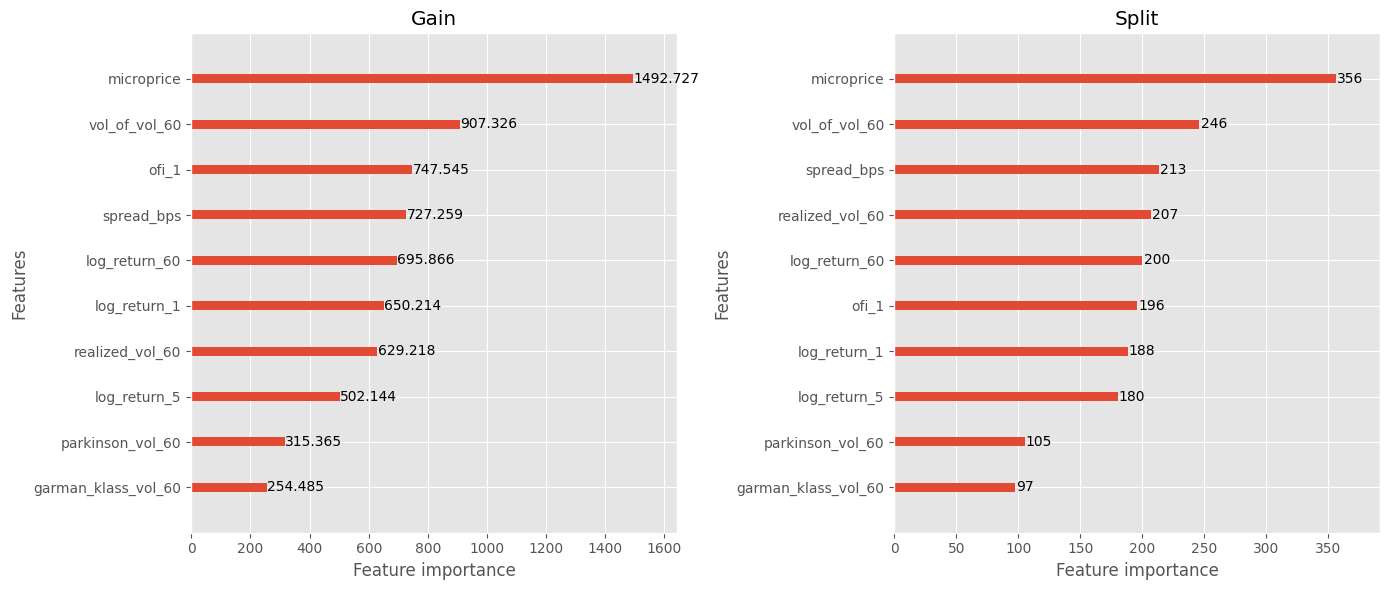

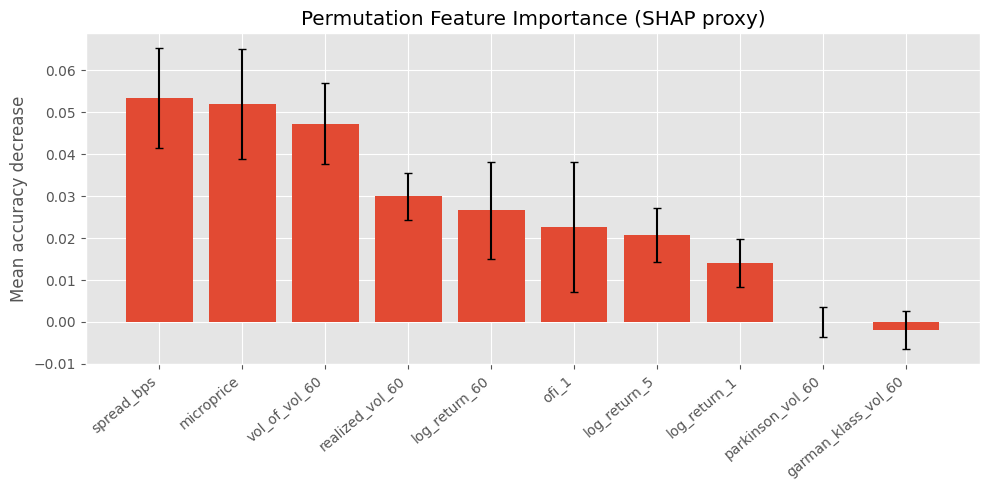

Note: for interactive SHAP plots run this cell in a live kernel.


In [6]:
import lightgbm as lgb
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lgb.plot_importance(model._model, ax=axes[0], importance_type="gain", title="Gain")
lgb.plot_importance(model._model, ax=axes[1], importance_type="split", title="Split")
plt.tight_layout()
plt.savefig("docs/figures/04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Xp = X.sample(min(300, len(X)), random_state=42)  # noqa: N806
yp = y.loc[Xp.index]
perm = permutation_importance(model._model, Xp, yp, n_repeats=5, random_state=42, n_jobs=1)
order = perm.importances_mean.argsort()[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    range(len(feature_cols)),
    perm.importances_mean[order],
    yerr=perm.importances_std[order],
    capsize=3,
)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in order], rotation=40, ha="right")
ax.set_ylabel("Mean accuracy decrease")
ax.set_title("Permutation Feature Importance (SHAP proxy)")
plt.tight_layout()
plt.savefig("docs/figures/04_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Note: for interactive SHAP plots run this cell in a live kernel.")

## 6. CPCV Path Sharpe Distribution

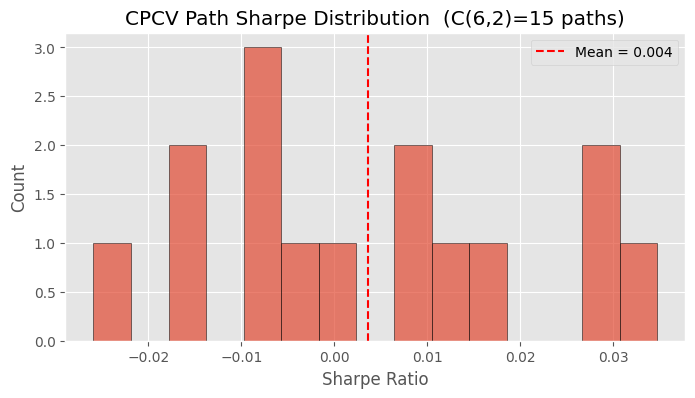

In [7]:
from tessera.cv.combinatorial_purged import CombinatorialPurgedKFold

cpcv = CombinatorialPurgedKFold(
    n_splits=6,
    n_test_splits=2,
    samples_info_sets=t1,
    pct_embargo=0.01,
)

path_sharpes = []
for _train_idx, val_idx in cpcv.split(X):
    preds = model.predict(X.iloc[val_idx])
    ret = fwd_ret.iloc[val_idx].values
    strat = preds.astype(float) * ret
    std = strat.std()
    path_sharpes.append(strat.mean() / std if std > 1e-12 else 0.0)

plt.figure(figsize=(8, 4))
plt.hist(path_sharpes, bins=15, edgecolor="black", alpha=0.7)
plt.axvline(
    np.mean(path_sharpes), color="red", linestyle="--", label=f"Mean = {np.mean(path_sharpes):.3f}"
)
plt.xlabel("Sharpe Ratio")
plt.ylabel("Count")
plt.title("CPCV Path Sharpe Distribution  (C(6,2)=15 paths)")
plt.legend()
plt.savefig("docs/figures/04_cpcv_sharpe_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 6 Report

### CV Sharpe and Deflated Sharpe

- **CV Sharpe (mean ± std)**: PurgedKFold Sharpe over all Optuna trials.
- **Deflated Sharpe (DSR)**: Bailey & López de Prado (2014) trial-count correction.
  DSR ≥ 0.95 → high confidence; < 0.75 → likely noise.
- On pure GBM synthetic data (zero alpha) expect low DSR — that is the correct result.

In [8]:
if card.cv_scores:
    print("=" * 60)
    print("PHASE 6 REPORT — Primary LightGBM Baseline")
    print("=" * 60)
    cv = card.cv_scores
    print(f"  Optuna trials:       {cv.n_trials}")
    print(f"  CV Sharpe (mean):    {cv.mean_sharpe:.4f}")
    print(f"  CV Sharpe (std):     {cv.std_sharpe:.4f}")
    print(f"  Deflated Sharpe:     {cv.deflated_sharpe:.4f}")
    print()
    print(f"  CPCV paths:          {len(path_sharpes)}")
    print(f"  CPCV Sharpe mean:    {np.mean(path_sharpes):.4f}")
    print(f"  CPCV Sharpe std:     {np.std(path_sharpes):.4f}")
    print(f"  CPCV range:          {np.min(path_sharpes):.4f} to {np.max(path_sharpes):.4f}")
    print()
    dsr = cv.deflated_sharpe
    if dsr >= 0.95:
        verdict = "STRONG — DSR>=0.95"
    elif dsr >= 0.75:
        verdict = "MODERATE — DSR in [0.75, 0.95)"
    else:
        verdict = "WEAK — DSR<0.75, likely noise (expected for pure GBM)"
    print(f"  Verdict:             {verdict}")
    print("=" * 60)

PHASE 6 REPORT — Primary LightGBM Baseline
  Optuna trials:       20
  CV Sharpe (mean):    0.0004
  CV Sharpe (std):     0.0328
  Deflated Sharpe:     0.0000

  CPCV paths:          15
  CPCV Sharpe mean:    0.0036
  CPCV Sharpe std:     0.0179
  CPCV range:          -0.0259 to 0.0347

  Verdict:             WEAK — DSR<0.75, likely noise (expected for pure GBM)


## 7. Save to Registry

In [9]:
from tessera.models.registry import ModelRegistry

registry = ModelRegistry()
path = registry.save_model(model, "primary")
registry.promote(path)
print(f"Model saved and promoted: {path}")
print()
print(model.get_model_card().model_dump_json(indent=2))

2026-05-17 21:07:24 [info     ] model_saved                    model_name=primary path=models/primary/5e148c6c_20260517_153724_645757


2026-05-17 21:07:24 [info     ] model_promoted                 model_name=primary path=models/primary/5e148c6c_20260517_153724_645757


Model saved and promoted: models/primary/5e148c6c_20260517_153724_645757

{
  "model_name": "lightgbm_primary",
  "model_type": "lightgbm_primary",
  "training_date": "2026-05-17T15:37:15.351607+00:00",
  "git_commit": "5e148c6c060e9308b60ca197713bc088052c4b17",
  "data_version": "",
  "features": [
    "log_return_1",
    "log_return_5",
    "log_return_60",
    "realized_vol_60",
    "parkinson_vol_60",
    "garman_klass_vol_60",
    "vol_of_vol_60",
    "ofi_1",
    "microprice",
    "spread_bps"
  ],
  "hyperparameters": {
    "boosting_type": "gbdt",
    "class_weight": null,
    "colsample_bytree": 1.0,
    "importance_type": "split",
    "learning_rate": 0.01720467529929385,
    "max_depth": 5,
    "min_child_samples": 20,
    "min_child_weight": 0.001,
    "min_split_gain": 0.0,
    "n_estimators": 100,
    "n_jobs": 1,
    "num_leaves": 241,
    "objective": "multiclass",
    "random_state": 42,
    "reg_alpha": 0.620396104701887,
    "reg_lambda": 0.027603248905793416,
    "s